In [1]:
# Ensure python (*.py) files are reloaded correctly while editing them
%load_ext autoreload
%autoreload 2

# Login to Hugging Face to be able to download the DINO model
This requires you to first request permission to the models [here](https://huggingface.co/facebook/dinov3-vit7b16-pretrain-lvd1689m)

Run the cell bellow, and generate a token on Huggingface here: https://huggingface.co/settings/tokens


In [2]:
from huggingface_hub import notebook_login, HfApi

api = HfApi()
try:
    who = api.whoami()
    print("logged in as:", who['name'])
except Exception:
    print("not logged in")
    notebook_login()

logged in as: tarkanyitomi


In [3]:
from few_shot.DINOv3Wrapper import DINOv3Wrapper
from mvtechDataset import ensure_mvtech_dataset_is_downloaded, get_categories, load_mvtec_data

dataset_path = ensure_mvtech_dataset_is_downloaded(".")
categories = get_categories(dataset_path)
print(categories)
category = "hazelnut"
num_shots = 4

reference_images, test_images, test_labels, test_masks = load_mvtec_data(
    dataset_path, category, num_shots
)

model = DINOv3Wrapper(
    model_name="facebook/dinov3-vits16-pretrain-lvd1689m",
    smaller_edge_size=1024
)

Dataset already exists at .\mvtec_anomaly_detection
['bottle', 'cable', 'capsule', 'carpet', 'grid', 'hazelnut', 'leather', 'metal_nut', 'pill', 'screw', 'tile', 'toothbrush', 'transistor', 'wood', 'zipper']
Loaded 4 reference images for hazelnut
Loaded 110 test images (70 anomalous, 40 normal)
Loading facebook/dinov3-vits16-pretrain-lvd1689m on cuda...
Model loaded! Hidden dim: 384, Register tokens: 4, Patch size: 16
Smaller edge size: 1024


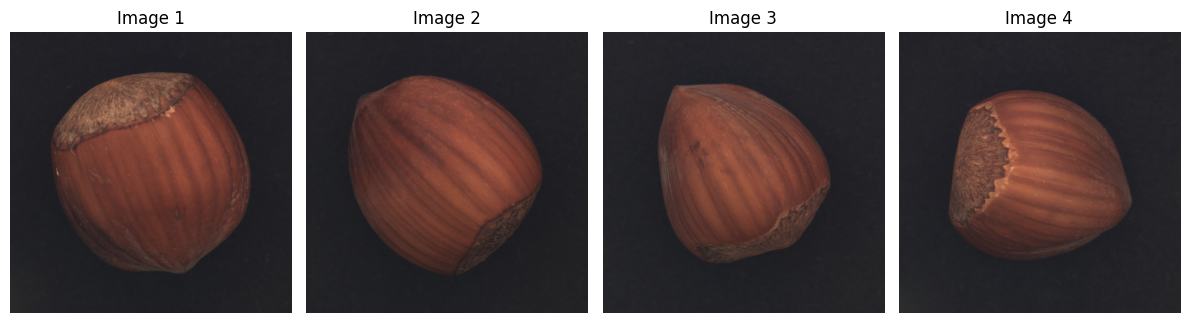

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(12, 6))

axes = axes.flatten()

for i, img in enumerate(reference_images[:4]):
    axes[i].imshow(img)
    axes[i].axis('off')
    axes[i].set_title(f'Image {i+1}')

plt.tight_layout()
plt.show()

## Build Memory Bank

Given the `n` reference images extract patch level feature vectors from each images.

In [5]:
from few_shot.build_memory_bank import build_memory_bank

# Build memory bank with rotation augmentation
nn_index, features_ref, num_features = build_memory_bank(
    model=model,
    reference_images=reference_images,
    use_rotation=True,
    normalize_features=True
)

print(f"\nMemory bank ready with {num_features} patches!")

Building memory bank from 4 images...
Rotation augmentation: True


Processing reference images:   0%|          | 0/4 [00:00<?, ?it/s]

Memory bank built! Index size: 131072

Memory bank ready with 131072 patches!


## Run Anomaly Detection

Detect anomalies on all test images using the memory bank.

In [6]:
from few_shot.detect_anomalies import detect_anomalies
from tqdm.auto import tqdm
import numpy as np

print(f"Running anomaly detection on {len(test_images)} test images...")

image_scores = []
anomaly_maps = []

for test_img in tqdm(test_images[:4], desc="Detecting anomalies"):
    score, anomaly_map, patch_scores = detect_anomalies(
        model=model,
        nn_index=nn_index,
        test_image=test_img,
        use_masking=True,
        k_neighbors=3,
        normalize_features=True
    )
    image_scores.append(score)
    anomaly_maps.append(anomaly_map)

image_scores = np.array(image_scores)
test_labels = np.array(test_labels)

print(f"Detection complete!")

Running anomaly detection on 110 test images...


Detecting anomalies:   0%|          | 0/4 [00:00<?, ?it/s]

Detection complete!


## Visualize Results

Display anomaly detection results for sample images (both normal and anomalous).

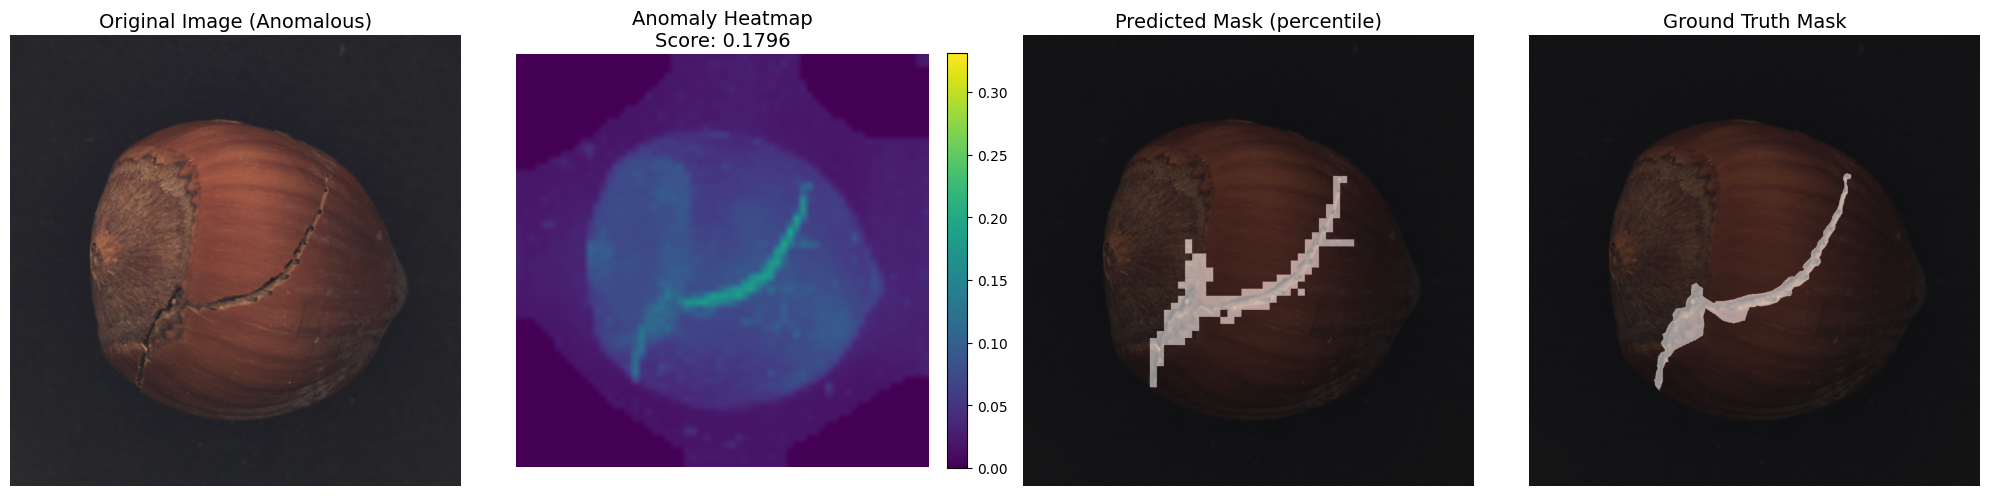

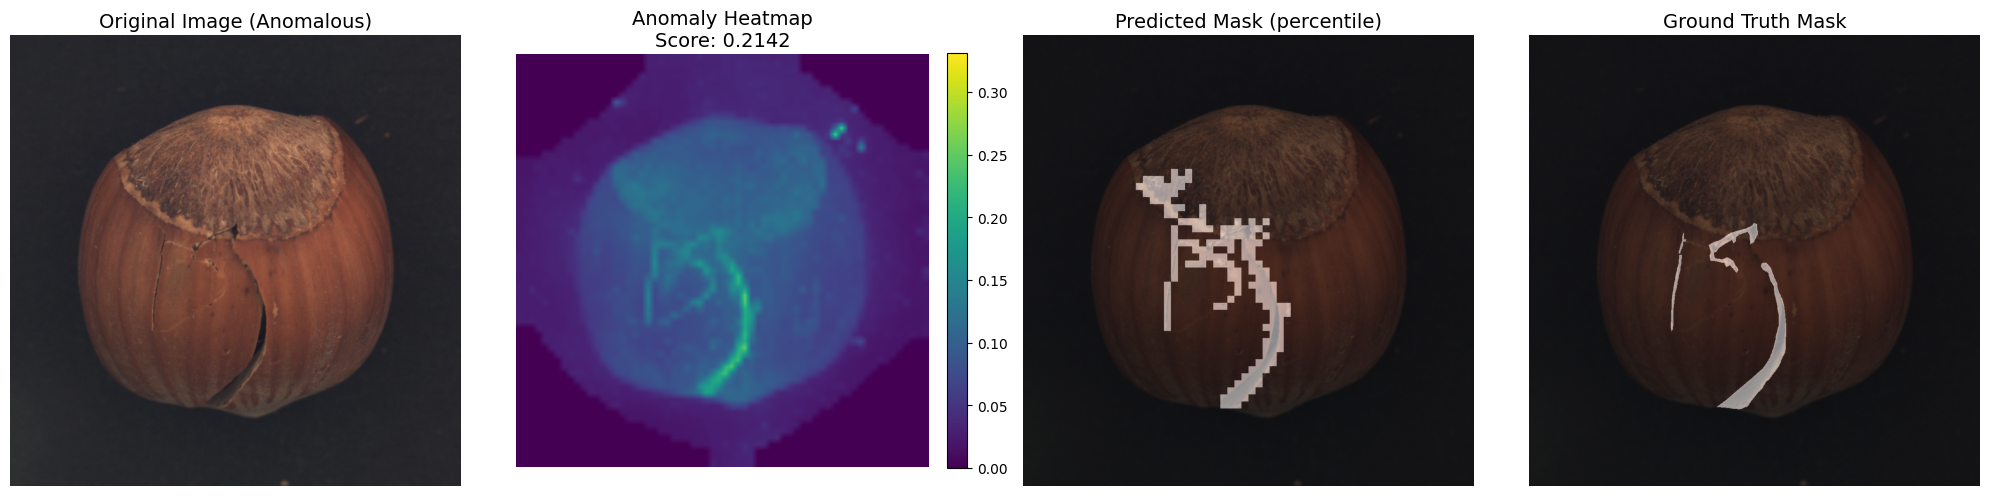

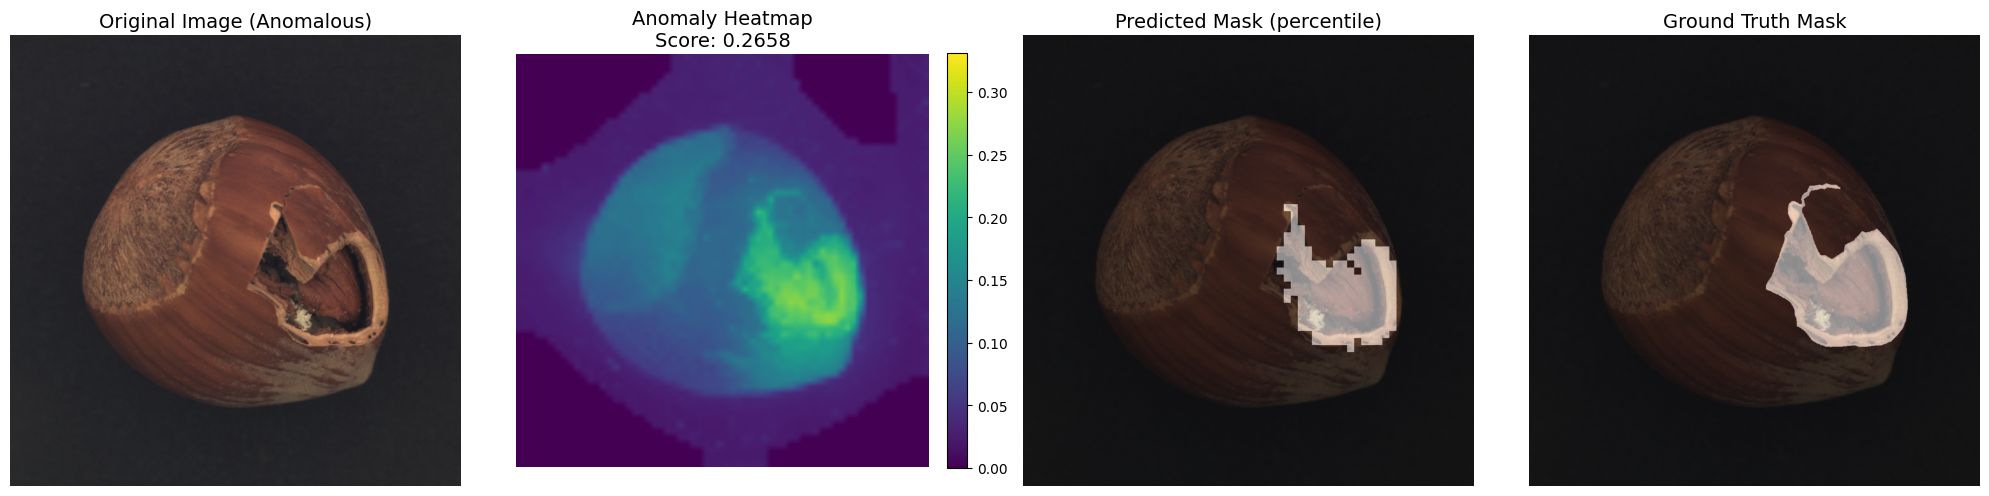

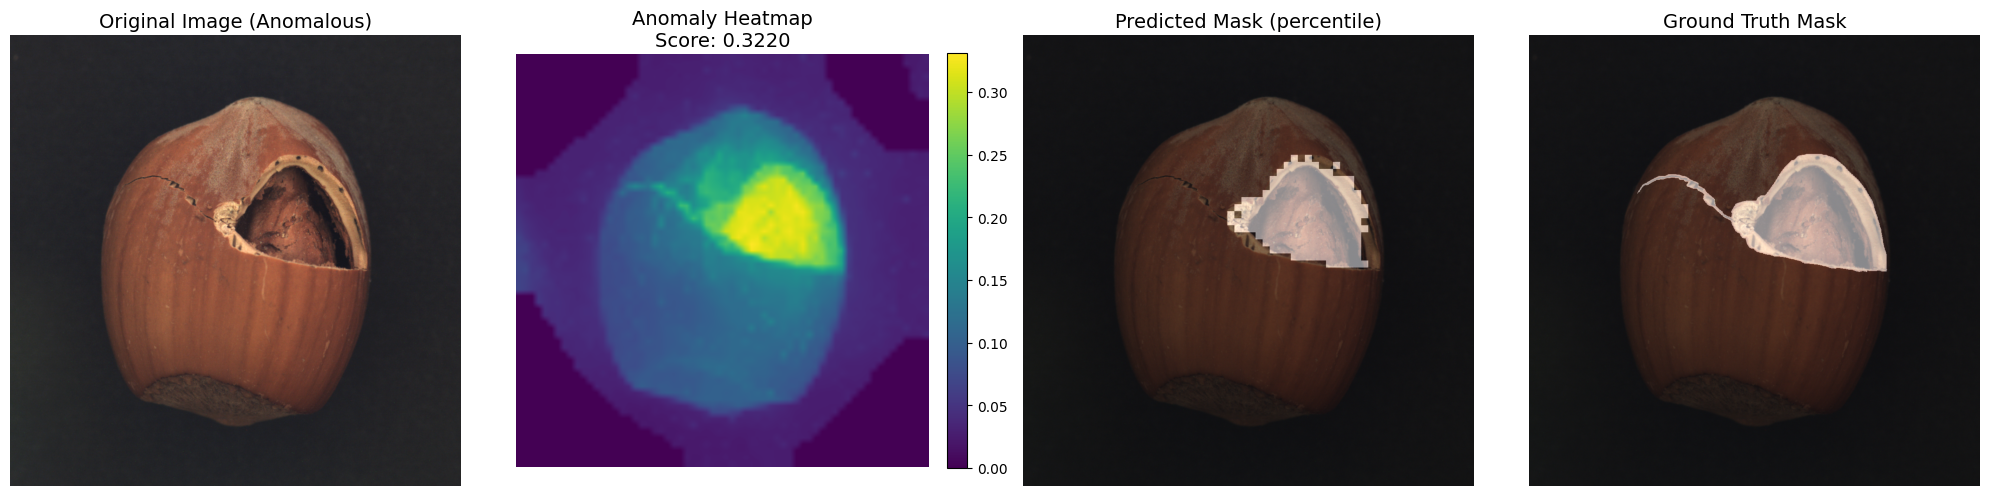

In [7]:
from evaluation.visualization import visualize_multiple_results

# Visualize results for diverse samples (3 normal + 3 anomalous)
visualize_multiple_results(
    images=test_images[:4],
    anomaly_maps=anomaly_maps,
    scores=image_scores,
    labels=test_labels[:4],
    ground_truth_masks=test_masks,
    num_display=6,
    sigma=0,
    segmentation_method='percentile'
)